# 07 - Evaluation

### Notebook Overview

Evaluate all three trained models on the held-out test set. Compare performance metrics, analyse residuals, and select the best model.

**Input:** `../data/x-test.csv`, `../data/y-test.csv`, `../models/*.pkl`

### 1 - Imports

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import joblib

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### 2 - Load Data and Models

In [2]:
X_test = pd.read_csv("../data/x-test.csv")
y_test = pd.read_csv("../data/y-test.csv").squeeze()

models = {
    "Linear Regression": joblib.load("../models/linear-regression.pkl"),
    "Random Forest": joblib.load("../models/random-forest.pkl"),
    "Gradient Boosting": joblib.load("../models/gradient-boosting.pkl"),
}

print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Models loaded: {list(models.keys())}")

Test set: 41 samples, 35 features
Models loaded: ['Linear Regression', 'Random Forest', 'Gradient Boosting']


### 3 - Test Set Predictions

In [3]:
predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test)

### 4 - Performance Metrics

Three complementary metrics:
- **MAE** (Mean Absolute Error): average dollar amount off. Most interpretable.
- **RMSE** (Root Mean Squared Error): penalises large errors more heavily than MAE. If RMSE is much higher than MAE, the model is making some big misses.
- **R2**: proportion of variance explained. 1.0 = perfect, 0.0 = no better than predicting the mean.

In [4]:
results = []
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)

# Format for display
display_df = results_df.copy()
display_df["MAE"] = display_df["MAE"].apply(lambda x: f"${x:,.0f}")
display_df["RMSE"] = display_df["RMSE"].apply(lambda x: f"${x:,.0f}")
display_df["R2"] = display_df["R2"].apply(lambda x: f"{x:.3f}")

print("Test Set Performance:")
print(display_df.to_string(index=False))

Test Set Performance:
            Model    MAE   RMSE    R2
Linear Regression $2,197 $3,335 0.859
    Random Forest $1,533 $2,195 0.939
Gradient Boosting $1,676 $2,466 0.923


### 5 - Actual vs Predicted

Points on the diagonal line represent perfect predictions. Points above the line are overestimates; below are underestimates.

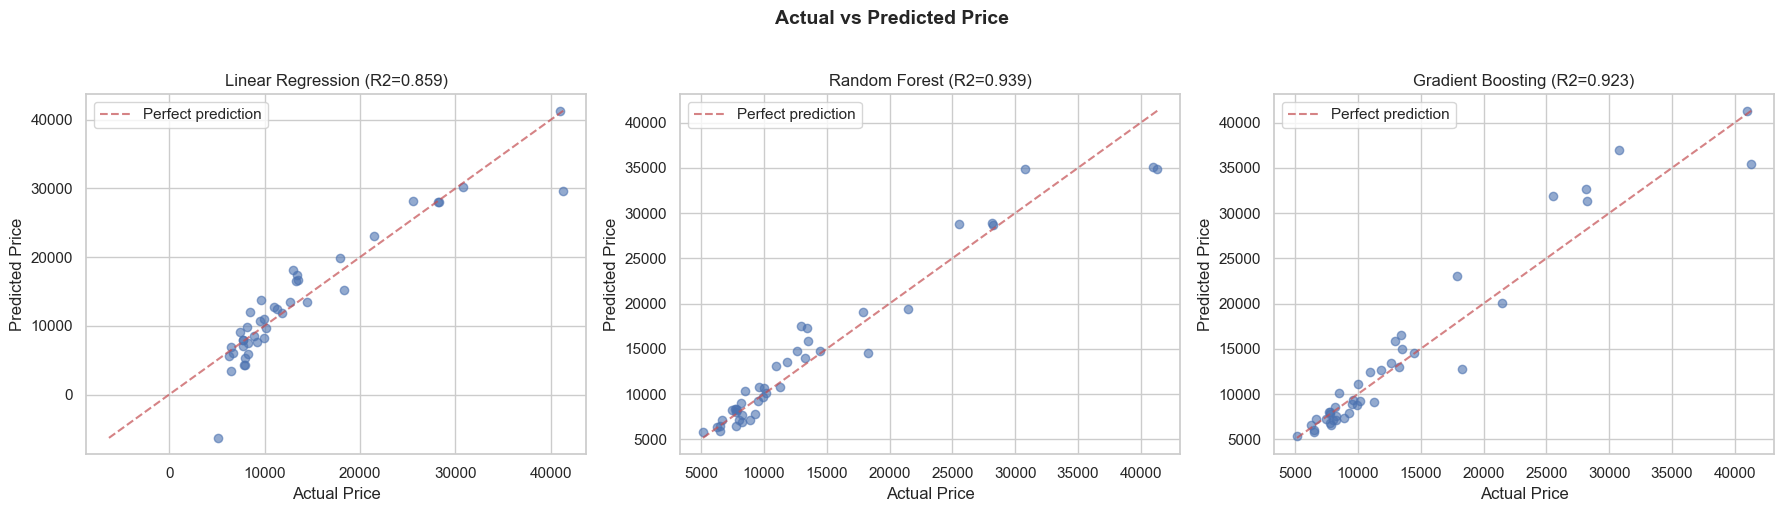

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.6)
    
    # Perfect prediction line
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", alpha=0.7, label="Perfect prediction")
    
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{name} (R2={r2:.3f})")
    ax.legend()

plt.suptitle("Actual vs Predicted Price", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/actual-vs-predicted.png", dpi=150, bbox_inches="tight")
plt.show()

### 6 - Residual Analysis

Residuals = actual - predicted. Ideally they should be randomly scattered around zero with no pattern. If you see a funnel shape (residuals growing with price), the model struggles more with expensive cars. A curve means the model is missing a non-linear relationship.

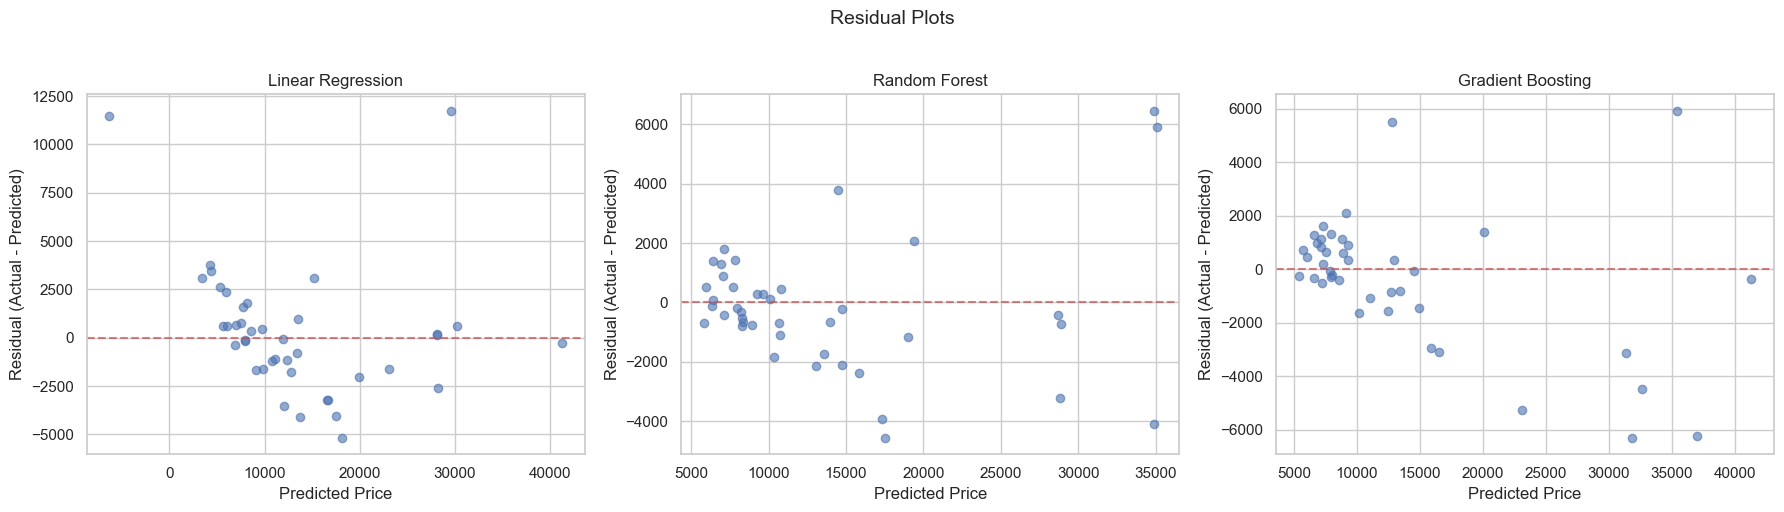

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6)
    ax.axhline(y=0, color="r", linestyle="--", alpha=0.7)
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(name)

plt.suptitle("Residual Plots", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../visualizations/residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### 7 - Residual Distribution

A histogram of residuals shows whether errors are symmetrically distributed. A bell shape centred at zero is ideal. Skew indicates the model systematically over- or under-predicts.

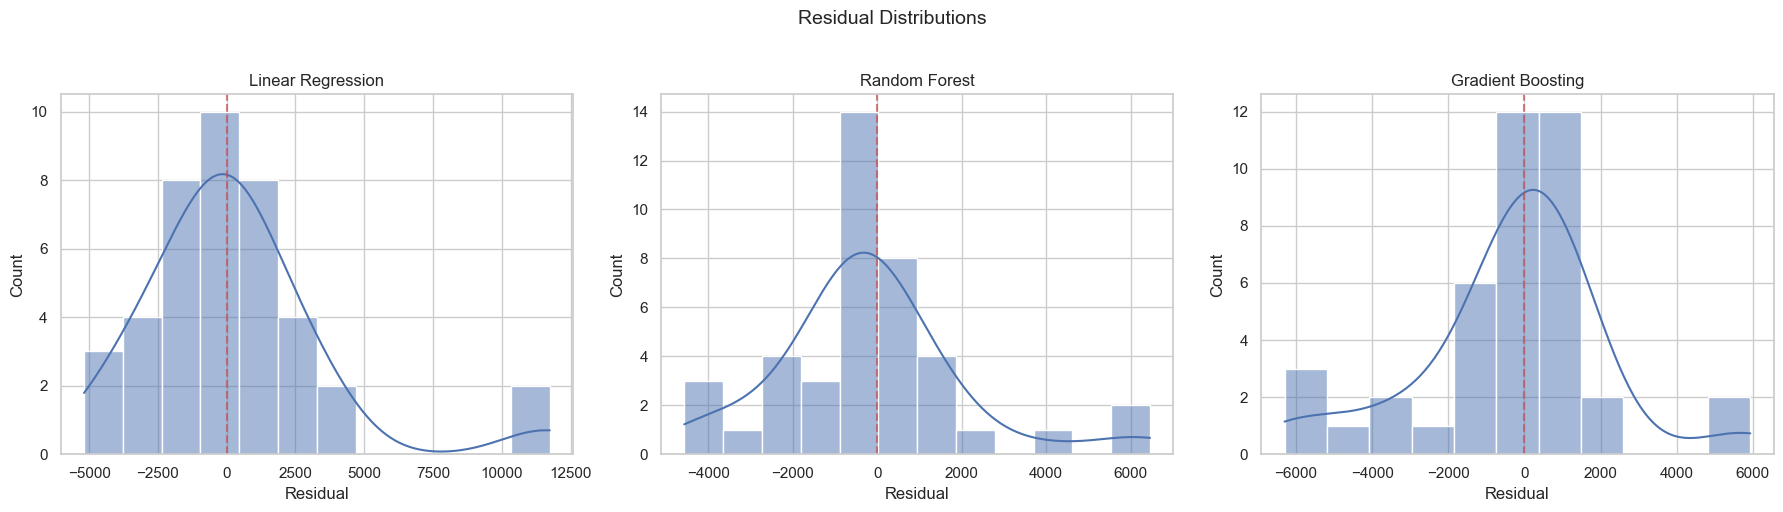

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, ax=ax)
    ax.axvline(x=0, color="r", linestyle="--", alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("Residual")

plt.suptitle("Residual Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../visualizations/residual-distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 8 - Feature Importance (Tree-Based Models)

Tree-based models can tell us which features mattered most for their predictions. This is useful for understanding what drives car prices and for explaining the model to stakeholders.

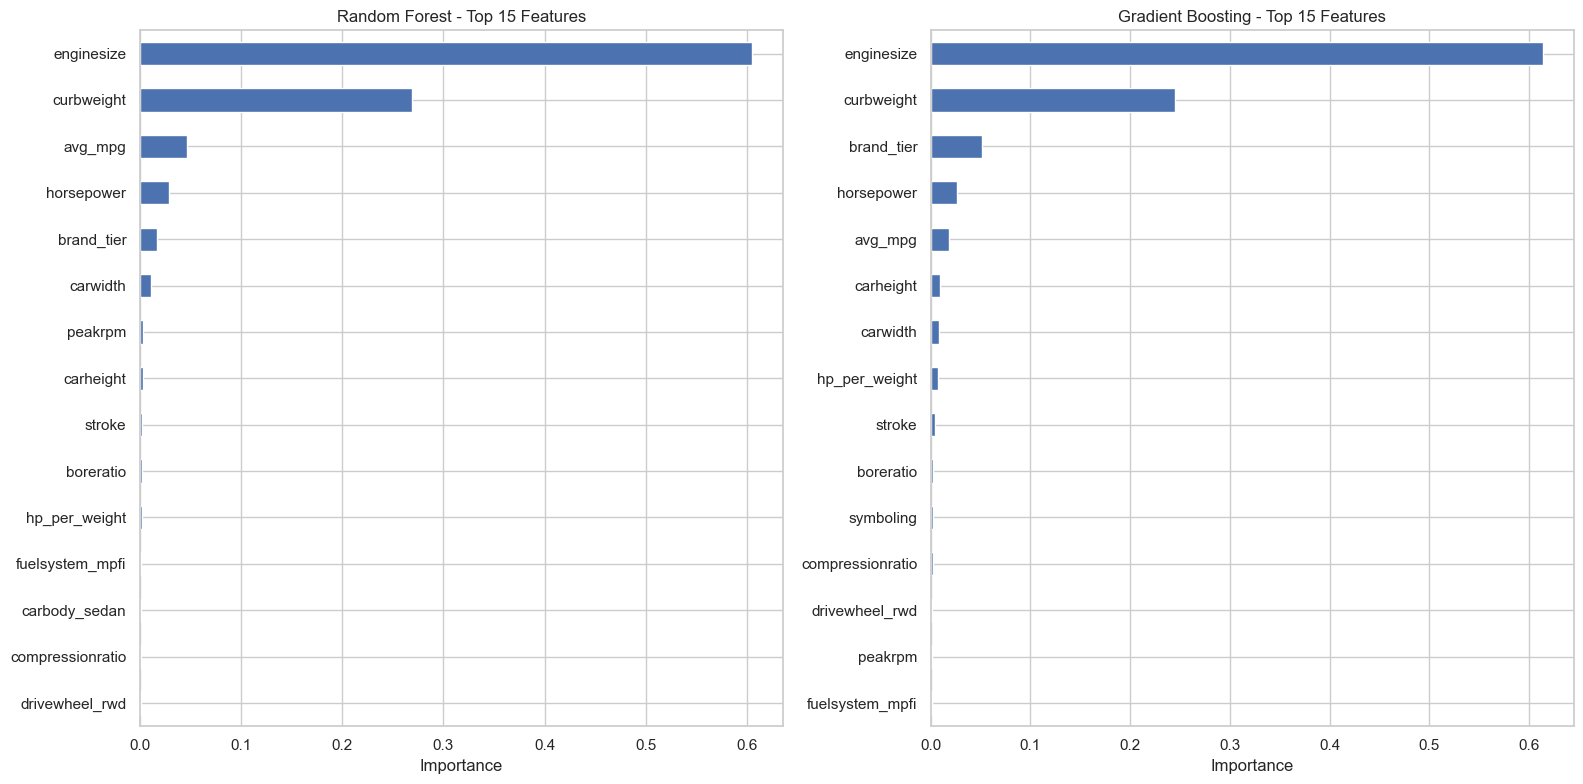

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, name in enumerate(["Random Forest", "Gradient Boosting"]):
    model = models[name]
    importance = pd.Series(model.feature_importances_, index=X_test.columns)
    top_15 = importance.nlargest(15)
    
    top_15.sort_values().plot.barh(ax=axes[i])
    axes[i].set_title(f"{name} - Top 15 Features")
    axes[i].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("../visualizations/feature-importance.png", dpi=150, bbox_inches="tight")
plt.show()

### 9 - Final Metrics

In [9]:
print("=" * 55)
print("FINAL TEST SET RESULTS")
print("=" * 55)
print(display_df.to_string(index=False))
print("=" * 55)

best = results_df.loc[results_df["R2"].idxmax()]
print(f"\nBest model: {best['Model']}")
print(f"  MAE:  ${best['MAE']:,.0f}")
print(f"  RMSE: ${best['RMSE']:,.0f}")
print(f"  R2:   {best['R2']:.3f}")

FINAL TEST SET RESULTS
            Model    MAE   RMSE    R2
Linear Regression $2,197 $3,335 0.859
    Random Forest $1,533 $2,195 0.939
Gradient Boosting $1,676 $2,466 0.923

Best model: Random Forest
  MAE:  $1,533
  RMSE: $2,195
  R2:   0.939


### 10 - Summary

**Test set results:**

| Model | MAE | RMSE | R2 |
|-------|-----|------|-----|
| Linear Regression | $2,197 | $3,335 | 0.859 |
| Random Forest | $1,533 | $2,195 | 0.939 |
| Gradient Boosting | $1,676 | $2,466 | 0.923 |

**Best model: Random Forest** (R2 = 0.939, MAE = $1,533)

**Key observations:**
- Random Forest outperformed Gradient Boosting on the test set, even though Gradient Boosting had a slight edge during cross-validation. This is not unusual with small datasets where the specific test split can favour one model over another.
- Linear Regression is a respectable baseline (R2 = 0.859) but both tree-based models capture non-linear patterns it misses.
- The gap between MAE and RMSE for Linear Regression ($2,197 vs $3,335) is larger than for the tree-based models, suggesting Linear Regression makes some particularly large errors on expensive cars.
- All models explain at least 86% of price variance, which is strong given the small dataset (205 rows total).